In [38]:
import pandas as pd

In [39]:
dataset=pd.read_csv('Mall_Customers.csv')
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [40]:
dataset.drop('CustomerID',axis=1,inplace=True)

In [41]:
dataset.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [42]:
dataset['Gender']=dataset['Gender'].map({
    'Male' : 1,
    'Female' :0
})

In [43]:
dataset.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [44]:
columns=dataset.columns
from sklearn.preprocessing import StandardScaler

ss=StandardScaler()

dataset=ss.fit_transform(dataset)

In [45]:
dataset=pd.DataFrame(dataset,columns=columns)

In [46]:
dataset.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


In [47]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(dataset)

    wcss.append(model.inertia_)

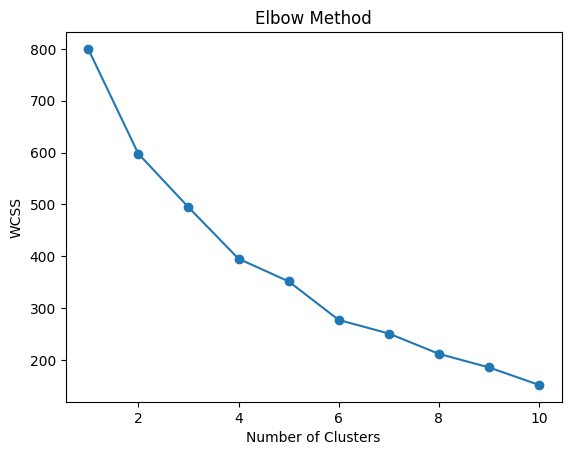

In [48]:
import matplotlib.pyplot as plt
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [49]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(dataset)

dataset["Cluster"] = clusters

In [50]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

score = silhouette_score(dataset, clusters)

print(score)

0.3805322046080448


In [51]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(dataset)

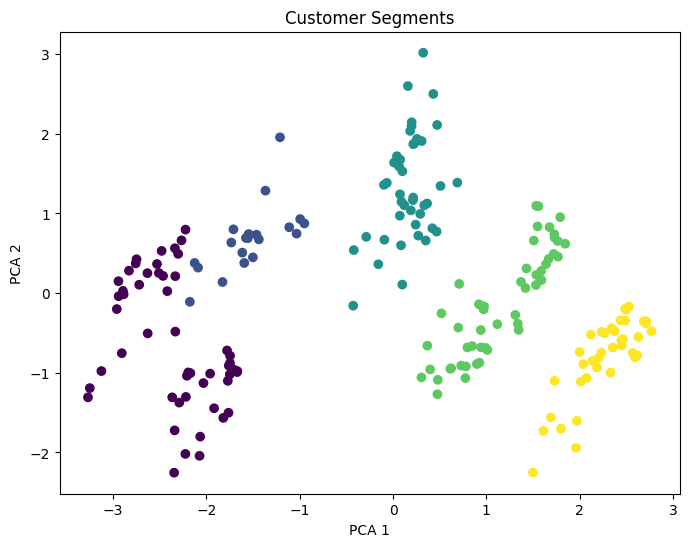

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments")

plt.show()